# [Parameter efficient fine tuning using LORA](https://arxiv.org/pdf/2106.09685.pdf)





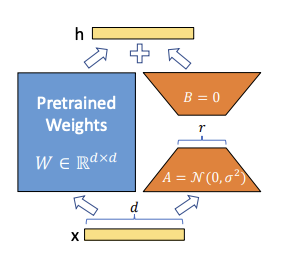

In [1]:
!pip install -q -U datasets
!pip install -q -U transformers[torch]
!pip install -q -U evaluate
!pip install -q -U peft
!pip install -q -U accelerate
!pip install -q -U torchinfo
!pip install -q -U neo4j
!pip install -q -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 32.0 MB/s eta 0:00:00


In [2]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import get_peft_config, PeftModel, PeftConfig, get_peft_model, LoraConfig, TaskType
from datasets import (
    Dataset,
    load_dataset
)
from torchinfo import summary
from datetime import datetime, time
from tqdm.notebook import tqdm
from neo4j import GraphDatabase
from typing import List, Dict, Any
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
from typing import Optional, Iterable, Dict, Any, List
from neo4j import GraphDatabase
from google.colab import userdata

import pandas as pd
import re
import math, os
import textwrap
import json
import time
import torch
import evaluate
import torch
import numpy as np
import transformers
import evaluate




In [3]:

# SETUP


load_dotenv()
def get_env(key: str, default: str = None):
    """Tries os.getenv first, then Colab userdata if available."""
    return os.getenv(key) or userdata.get(key) or default

NEO4J_URI  = get_env("NEO4J_URI")   # bolt:// or neo4j://
NEO4J_USER = get_env("NEO4J_USER")
NEO4J_PASS = get_env("NEO4J_PASS")
NEO4J_DATABASE = get_env("NEO4J_DATABASE")

DB_HOST = get_env("POSTGRES_DB_HOST")
DB_PORT = int(get_env("POSTGRES_DB_PORT"))
DB_NAME = get_env("POSTGRES_DB_NAME")
DB_USER = get_env("POSTGRES_DB_USER")
DB_PASS = get_env("POSTGRES_DB_PASS")

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_url, echo=False)
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

quantization_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=torch.bfloat16
)



In [4]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')


# Define your directory
output_folder = "/content/drive/MyDrive/mids266_project/output"
data_folder = "/content/drive/MyDrive/mids266_project/data"



Mounted at /content/drive


In [5]:

smol_path = "HuggingFaceTB/SmolLM3-3B"
gemma_checkpoint = "google/gemma-2-9b-it"
model_checkpoint = smol_path


## Load  Dataset


In [6]:
V2_outputs = pd.read_sql("SELECT * FROM complete_output WHERE model_type = 'V2';", engine)

V2_outputs

,policy_id,section_id,output,prompt_text,model_type,mds,judge,total_score,source_framework,org_text,split_label
0,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,train
1,CL_0002-ISP-v1.0,CL_0002-ISP-v1.0:S3.5,"All activity on business systems, computer equ...",[INSTRUCTION]\nDraft the policy section titled...,V2,17.327435,97.831276,65.629740,SOC2,[COMPANY_NAME] shall establish coverage for al...,train
2,CL_0003-RMP-v1.1,CL_0003-RMP-v1.1:S3.2.1,"All employees, contractors, and relevant third...",[INSTRUCTION]\nDraft the policy section titled...,V2,12.784695,99.948965,65.083257,SOC2,"Risk management processes are developed, imple...",val
3,CL_0005-PVM-v2.0,CL_0005-PVM-v2.0:S3.4,Requests for exceptions to the patching proces...,[INSTRUCTION]\nDraft the policy section titled...,V2,30.357313,99.950440,72.113189,NIST CSF,Patches on production systems (e.g. servers an...,train
4,CL_0007-ACP-v1.0,CL_0007-ACP-v1.0:S3.6,Data transmitted over insecure ports and proto...,[INSTRUCTION]\nDraft the policy section titled...,V2,0.000010,70.976350,42.585814,NIST CSF,Network integrity is protected using technique...,train
...,...,...,...,...,...,...,...,...,...,...,...
1449,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.5.3,"When transferring risk, a documented risk tran...",[INSTRUCTION]\nDraft the policy section titled...,V2,50.900041,99.524480,80.074704,NIST CSF,"In the event where a risk must be transferred,...",train
1450,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.6,Risk assessments will be conducted on an annua...,[INSTRUCTION]\nDraft the policy section titled...,V2,23.269856,91.367652,64.128534,NIST CSF,[COMPANY_NAME] shall conduct an annual risk as...,train
1451,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.7,"All employees, contractors, and relevant third...",[INSTRUCTION]\nDraft the policy section titled...,V2,34.901390,99.087436,73.413018,NIST CSF,[COMPANY_NAME] will provide training and aware...,train
1452,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.8,All identified risks will be documented and pr...,[INSTRUCTION]\nDraft the policy section titled...,V2,29.432520,99.617552,71.543539,NIST CSF,If the risk rating for [COMPANY_NAME] is not a...,train


In [7]:
v2_output_train_dataset = V2_outputs[V2_outputs['split_label'] == 'train'].sample(frac=0.2).reset_index(drop=True)
v2_output_dev_dataset = V2_outputs[V2_outputs['split_label'] == 'val'].sample(frac=0.1).reset_index(drop=True)

In [8]:
# add a new column to v2_output_train_dataset which convertes mds score to a number between 0 and 1
min_mds = np.min(v2_output_train_dataset["mds"] )
max_mds = np.max(v2_output_train_dataset["mds"] )
v2_output_train_dataset["mds_normalized"] = (v2_output_train_dataset["mds"] - min_mds) / (max_mds - min_mds)

min_mds = np.min(v2_output_train_dataset["mds_normalized"] )
max_mds = np.max(v2_output_train_dataset["mds_normalized"] )
median_mds = np.median(v2_output_train_dataset["mds_normalized"] )
# change mds_normalized to only 4 digits after decimal
v2_output_train_dataset["mds_normalized"] = v2_output_train_dataset["mds_normalized"].round(4)
print(min_mds, max_mds, median_mds)

0.0 1.0 0.4768373122096911


In [9]:
# find max length of v2_output_train_dataset['output']
max_len = 0
for i in range(len(v2_output_train_dataset['output'])):
  if len(v2_output_train_dataset['output'][i]) > max_len:
    max_len = len(v2_output_train_dataset['output'][i])
print(max_len)

1262


In [10]:
MAX_SEQUENCE_LENGTH = 1600

## Load Causal LLM model and Tokenizer.

`AutoModelForCausalLM` is a Generic huggingface transformers library. We freeze the model layers explicitly since the LORA adapters will be used to train smaller weight matrices

In [11]:

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

model = AutoModelForCausalLM.from_pretrained(
    model_checkpoint,
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=quantization_config
)



tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.18G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/182 [00:00<?, ?B/s]

## LORA setup
setup the lora config and call function to get the peft version of the model that adds the extra adapters and layers

In [12]:
# Configure LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # Task type
    r=16,                          # Rank of LoRA matrices (8, 16, 32, 64)
    lora_alpha=32,                 # Scaling parameter (usually 2*r)
    lora_dropout=0.05,             # Dropout probability
    target_modules=[               # Modules to apply LoRA to
        "q_proj",    # Query projection
        "k_proj",    # Key projection
        "v_proj",    # Value projection
        "o_proj",    # Output projection
        "gate_proj", # MLP gate
        "up_proj",   # MLP up
        "down_proj"  # MLP down
    ],
    bias="none",                   # Don't train bias parameters
    base_model_name_or_path=model_checkpoint # Specify the base model checkpoint
)



In [13]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Enable gradient checkpointing and ensure input gradients are tracked
model.config.use_cache = False
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

trainable params: 30,228,480 || all params: 3,105,327,104 || trainable%: 0.9734


In [14]:
_= model.to("cuda")

## Setup training arguments and train model

In [15]:
# Format data for instruction tuning
def format_data(prompts, outputs, scores, threshold=0.5):
    data = []
    for prompt, output, score in zip(prompts, outputs, scores):
        if score >= threshold:  # Filter by quality
            # Format as instruction-response
            formatted_text = f"""<|im_start|>user
            {prompt}<|im_end|>
            <|im_start|>assistant
            {output}<|im_end|>"""

            data.append({"text": formatted_text})

    return Dataset.from_list(data)

# Create dataset
train_dataset = format_data(v2_output_train_dataset['prompt_text'], v2_output_train_dataset['output'], v2_output_train_dataset['mds_normalized'])

In [16]:
# Tokenization function
def tokenize_function(examples):
    # Tokenize
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQUENCE_LENGTH,
        padding="max_length",
        return_tensors=None
    )

    # For causal LM, labels = input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized


    # Apply tokenization
tokenized_dataset = train_dataset.map(
    tokenize_function,
    remove_columns=["text"],
    batched=True
)

Map:   0%|          | 0/105 [00:00<?, ? examples/s]

In [17]:
LORA_OUTPUT_DIR = "./smolm-lora-adapters/"

training_args = TrainingArguments(
    output_dir=LORA_OUTPUT_DIR,          # Where to save
    num_train_epochs=3,                      # Number of epochs
    per_device_train_batch_size=1,           # Batch size per GPU (reduced to 1)
    gradient_accumulation_steps=16,          # Accumulate gradients (increased to 16 for effective batch = 16)
    learning_rate=2e-4,                      # Learning rate (higher for LoRA)
    fp16=True,                               # Mixed precision training
    logging_steps=10,                        # Log every 10 steps
    save_strategy="epoch",                   # Save after each epoch
    save_total_limit=2,                      # Keep only 2 checkpoints
    warmup_steps=50,                         # Warmup steps
    optim="adamw_torch",                     # Optimizer
    report_to="none",                        # Disable wandb/tensorboard
    remove_unused_columns=False,             # Keep all columns
    gradient_checkpointing=True              # Enable gradient checkpointing for memory saving
)




In [18]:
from transformers import DataCollatorForLanguageModeling

# Data collator for causal LM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Not masked LM, it's causal LM
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

# Train the model
trainer.train()

Step,Training Loss
10,2.358900


Step,Training Loss
10,2.358900
20,1.798400


TrainOutput(global_step=21, training_loss=2.045507306144351, metrics={'train_runtime': 951.6284, 'train_samples_per_second': 0.331, 'train_steps_per_second': 0.022, 'total_flos': 8596200259584000.0, 'train_loss': 2.045507306144351, 'epoch': 3.0})

In [19]:
# Save only LoRA adapters (small ~50-100MB)
model.save_pretrained(LORA_OUTPUT_DIR)
tokenizer.save_pretrained(LORA_OUTPUT_DIR)

print("LoRA adapters saved!")

LoRA adapters saved!


In [20]:


# Load LoRA configuration
config = PeftConfig.from_pretrained(LORA_OUTPUT_DIR)

# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=quantization_config # Added quantization_config here
)

# Load LoRA adapters on top of base model
model = PeftModel.from_pretrained(base_model,LORA_OUTPUT_DIR)

# Ensure the entire model is on the CUDA device
model.to("cuda")

# Set to evaluation mode
model.eval()

# Generate text
prompt = v2_output_dev_dataset.iloc[0]["prompt_text"]
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_SEQUENCE_LENGTH,  # Added to ensure total length is sufficient
        temperature=0.7,
        do_sample=True,
        top_p=0.9
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INSTRUCTION]
Draft the policy section titled: "Potential Business Impacts"
for the overall policy: "Risk Management Policy".
Audience: all employees, contractors, and relevant third parties.

Focus exclusively on producing the final policy text itself (no headings, no prefaces).

[ONTOLOGY CONTEXT]
Below is the ontology for relevant cybersecurity concepts tied to this policy.
Use the definitions, relationships, required behaviors, and expectations exactly as provided.
Do not create new ontology items.

- policy.behavior.scope.assets: Assets in Scope — key_phrases: business systems, computer equipment, electronic and computing devices, information assets, internal networks
- policy.behavior.systems.communication_channels: Communication Channels — key_phrases: Internet/intranet, blogging, email, instant messaging, newsgroups
- compliance.frameworks: Compliance Frameworks — key_phrases: gdpr, hipaa, iso 27001, nist 800-53, soc 2
- data.sensitivity: Data Sensitivity Level — key_phrases: f

## Run a sample evaluation

## Size of checkpoints

In [25]:
# print and check size of checkpoint. As expected the model size is much smaller that a typical bert checkpoint
!ls -lh ./smolm-lora-adapters/


total 132M
-rw-r--r-- 1 root root 1.1K Nov 22 15:07 adapter_config.json
-rw-r--r-- 1 root root 116M Nov 22 15:07 adapter_model.safetensors
-rw-r--r-- 1 root root 5.5K Nov 22 15:07 chat_template.jinja
drwxr-xr-x 2 root root 4.0K Nov 22 15:02 checkpoint-14
drwxr-xr-x 2 root root 4.0K Nov 22 15:07 checkpoint-21
-rw-r--r-- 1 root root 5.1K Nov 22 15:07 README.md
-rw-r--r-- 1 root root  289 Nov 22 15:07 special_tokens_map.json
-rw-r--r-- 1 root root  50K Nov 22 15:07 tokenizer_config.json
-rw-r--r-- 1 root root  17M Nov 22 15:07 tokenizer.json
